In [1]:
import torch
import torch.nn as nn

# nn.GELU (implemented)
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x,3)) 
        ))

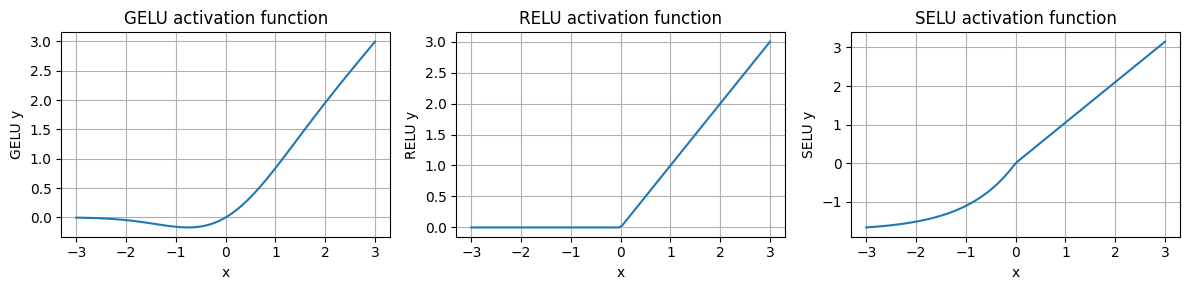

In [10]:
import matplotlib.pyplot as plt

gelu, relu, selu = GELU(), nn.ReLU(), nn.SELU()

x = torch.linspace(-3,3,100)
y_gelu, y_relu, y_selu = gelu(x), relu(x), selu(x)

plt.figure(figsize=(12,3))
for i, (y, label) in \
        enumerate(zip( [y_gelu,y_relu, y_selu] , ['GELU','RELU', 'SELU'] ), 1):
    plt.subplot(1,3, i)
    plt.plot(x,y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label} y")
    plt.grid(True)
plt.tight_layout()
plt.show()

# Feedforward Network

In [11]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "embedding_dim": 768,
    "num_of_heads": 12,
    "num_of_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False    
}

In [12]:
class Feedforward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(config['embedding_dim'] , 4*config['embedding_dim']),
            GELU(),
            nn.Linear(4*config['embedding_dim'] , config['embedding_dim'])            
        ) 
        
    def forward(self,x):
        return self.layers(x)

In [13]:
ffn = Feedforward(GPT_CONFIG_124M)

inputs = torch.rand(2, 3, 768)  # 2,3,embedding_dim
out = ffn(inputs)
out.shape

torch.Size([2, 3, 768])